In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import json

DATA_DIR = Path("data")

train_df = pd.read_csv(DATA_DIR / "unimib_train.csv")
val_df   = pd.read_csv(DATA_DIR / "unimib_val.csv")
test_df  = pd.read_csv(DATA_DIR / "unimib_test.csv")

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print(train_df.head())
print(train_df.columns[:20])
print(train_df.columns[-20:])

Train: (1421967, 7)
Val: (177727, 7)
Test: (177727, 7)
   ID  t        ax        ay        az  label       mag
0   0  0  1.463904  0.267338 -0.240852      1 -0.448149
1   0  1  1.407320  0.321725 -0.271622      1 -0.466154
2   0  2  1.399128  0.337630 -0.347673      1 -0.445171
3   0  3  1.492430  0.334661 -0.307134      1 -0.356161
4   0  4  1.549750  0.300181 -0.192982      1 -0.338196
Index(['ID', 't', 'ax', 'ay', 'az', 'label', 'mag'], dtype='str')
Index(['ID', 't', 'ax', 'ay', 'az', 'label', 'mag'], dtype='str')


In [3]:
print(train_df.dtypes)
print(train_df.columns.tolist())

ID         int64
t          int64
ax       float64
ay       float64
az       float64
label      int64
mag      float64
dtype: object
['ID', 't', 'ax', 'ay', 'az', 'label', 'mag']


In [4]:
def inspect_split(df, name):
    print(f"\n{name} split")
    print("-" * 40)

    # Each ID should contain exactly 151 time steps
    window_lengths = df.groupby("ID").size()
    print("Number of windows:", len(window_lengths))
    print("Window length min:", window_lengths.min())
    print("Window length max:", window_lengths.max())

    # Each ID should have only one label
    label_counts_per_id = df.groupby("ID")["label"].nunique()
    print("IDs with more than one label:", (label_counts_per_id > 1).sum())

    # Label distribution per window, not per row
    window_labels = df.groupby("ID")["label"].first()
    print("\nLabel counts per window:")
    print(window_labels.value_counts().sort_index())


inspect_split(train_df, "Train")
inspect_split(val_df, "Val")
inspect_split(test_df, "Test")


Train split
----------------------------------------
Number of windows: 9417
Window length min: 151
Window length max: 151
IDs with more than one label: 0

Label counts per window:
label
1      228
2      317
3     1342
4     1556
5      726
6      597
7     1024
8      233
9      157
10     412
11     394
12     400
13     512
14     372
15     337
16     395
17     415
Name: count, dtype: int64

Val split
----------------------------------------
Number of windows: 1177
Window length min: 151
Window length max: 151
IDs with more than one label: 0

Label counts per window:
label
1      29
2      40
3     168
4     194
5      91
6      74
7     128
8      29
9      20
10     51
11     49
12     50
13     64
14     47
15     42
16     49
17     52
Name: count, dtype: int64

Test split
----------------------------------------
Number of windows: 1177
Window length min: 151
Window length max: 151
IDs with more than one label: 0

Label counts per window:
label
1      29
2      40
3     168


In [5]:
FEATURE_COLS = ["ax", "ay", "az"]

def build_windows(df, feature_cols=FEATURE_COLS):
    # Sort by ID and time so each motion window is ordered correctly
    df_sorted = df.sort_values(["ID", "t"])

    # Make sure every window has exactly 151 time steps
    window_lengths = df_sorted.groupby("ID").size()
    assert window_lengths.min() == 151, "Some windows are shorter than 151"
    assert window_lengths.max() == 151, "Some windows are longer than 151"

    X_list = []
    y_list = []

    # Each ID corresponds to one full motion sample
    for _, group in df_sorted.groupby("ID", sort=True):
        X_window = group[feature_cols].values.astype(np.float32)
        y_label = int(group["label"].iloc[0])

        X_list.append(X_window)
        y_list.append(y_label)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.int32)

    return X, y


X_train, y_train_multi = build_windows(train_df)
X_val, y_val_multi = build_windows(val_df)
X_test, y_test_multi = build_windows(test_df)

print("X_train:", X_train.shape)
print("y_train_multi:", y_train_multi.shape)

print("X_val:", X_val.shape)
print("y_val_multi:", y_val_multi.shape)

print("X_test:", X_test.shape)
print("y_test_multi:", y_test_multi.shape)

print("Unique train labels:", np.unique(y_train_multi))

X_train: (9417, 151, 3)
y_train_multi: (9417,)
X_val: (1177, 151, 3)
y_val_multi: (1177,)
X_test: (1177, 151, 3)
y_test_multi: (1177,)
Unique train labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [6]:
def to_binary_labels(y_multi):
    # UniMiB-SHAR label convention:
    # 1–9   = activities of daily living / normal
    # 10–17 = falls
    return (y_multi >= 10).astype(np.int32)


y_train = to_binary_labels(y_train_multi)
y_val = to_binary_labels(y_val_multi)
y_test = to_binary_labels(y_test_multi)

print("Train binary counts [normal, fall]:", np.bincount(y_train))
print("Val binary counts [normal, fall]:", np.bincount(y_val))
print("Test binary counts [normal, fall]:", np.bincount(y_test))

Train binary counts [normal, fall]: [6180 3237]
Val binary counts [normal, fall]: [773 404]
Test binary counts [normal, fall]: [773 404]


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

model = models.Sequential([
    layers.Input(shape=(151, 3)),

    layers.Conv1D(8, kernel_size=5, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(16, kernel_size=5, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 151, 8)            128       
                                                                 
 max_pooling1d (MaxPooling1  (None, 75, 8)             0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 75, 16)            656       
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 37, 16)            0         
 g1D)                                                            
                                                                 
 flatten (Flatten)           (None, 592)               0         
                                                                 
 dense (Dense)               (None, 16)                9

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
295/295 [==============================] - 1s 1ms/step - loss: 0.2321 - accuracy: 0.9080 - precision: 0.9036 - recall: 0.8199 - val_loss: 0.1440 - val_accuracy: 0.9524 - val_precision: 0.9028 - val_recall: 0.9653
Epoch 2/40
295/295 [==============================] - 0s 1ms/step - loss: 0.1249 - accuracy: 0.9589 - precision: 0.9292 - recall: 0.9530 - val_loss: 0.1217 - val_accuracy: 0.9609 - val_precision: 0.9182 - val_recall: 0.9728
Epoch 3/40
295/295 [==============================] - 0s 1ms/step - loss: 0.0996 - accuracy: 0.9694 - precision: 0.9445 - recall: 0.9679 - val_loss: 0.1031 - val_accuracy: 0.9720 - val_precision: 0.9470 - val_recall: 0.9728
Epoch 4/40
295/295 [==============================] - 0s 1ms/step - loss: 0.0856 - accuracy: 0.9752 - precision: 0.9527 - recall: 0.9762 - val_loss: 0.0963 - val_accuracy: 0.9703 - val_precision: 0.9489 - val_recall: 0.9653
Epoch 5/40
295/295 [==============================] - 0s 1ms/step - loss: 0.0773 - accuracy: 0.9747 - pr

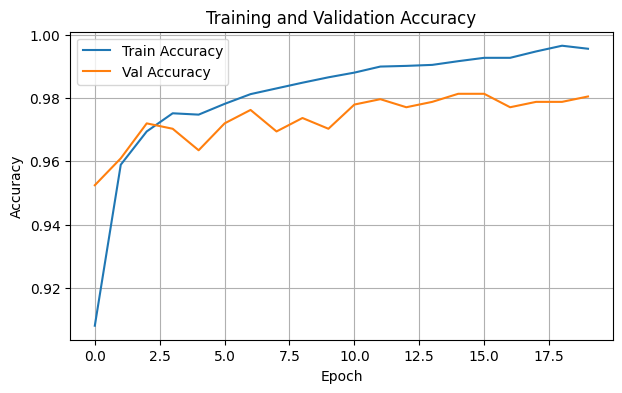

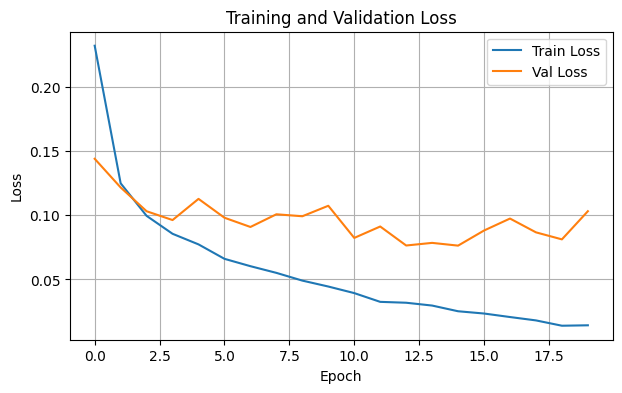

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)
print("Test precision:", test_precision)
print("Test recall:", test_recall)

Test loss: 0.06603963673114777
Test accuracy: 0.9821580052375793
Test precision: 0.9659367203712463
Test recall: 0.9826732873916626


37/37 [==============================] - 0s 443us/step
              precision    recall  f1-score   support

      normal       0.99      0.98      0.99       773
        fall       0.97      0.98      0.97       404

    accuracy                           0.98      1177
   macro avg       0.98      0.98      0.98      1177
weighted avg       0.98      0.98      0.98      1177



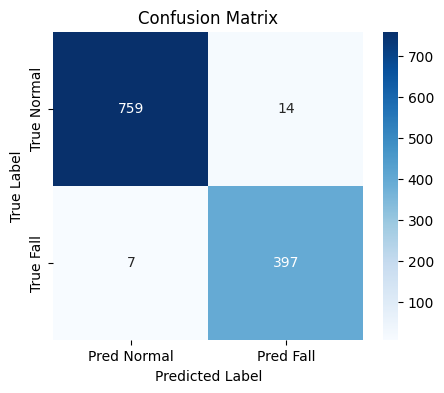

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

print(classification_report(
    y_test,
    y_pred,
    target_names=["normal", "fall"]
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Normal", "Pred Fall"],
    yticklabels=["True Normal", "True Fall"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [14]:
import os

def file_size_kb(filepath):
    return os.path.getsize(filepath) / 1024

model.save("fall_detection_cnn_float32.keras")
print("Saved Keras float32 CNN model.")

Saved Keras float32 CNN model.


In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float_model = converter.convert()

float_tflite_path = "fall_detection_cnn_float32.tflite"

with open(float_tflite_path, "wb") as f:
    f.write(tflite_float_model)

print("Float TFLite model size:", file_size_kb(float_tflite_path), "KB")

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpaqx31hsd/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpaqx31hsd/assets


Float TFLite model size: 45.421875 KB


2026-05-19 18:01:26.627746: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 18:01:26.627755: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 18:01:26.627890: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpaqx31hsd
2026-05-19 18:01:26.628364: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 18:01:26.628368: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpaqx31hsd
2026-05-19 18:01:26.629306: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-19 18:01:26.629711: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 18:01:26.646810: I tensorflow/cc/saved_model/loader.

In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_dynamic_model = converter.convert()

dynamic_tflite_path = "fall_detection_cnn_dynamic.tflite"

with open(dynamic_tflite_path, "wb") as f:
    f.write(tflite_dynamic_model)

print("Dynamic quantized model size:", file_size_kb(dynamic_tflite_path), "KB")

INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpiecpjlqe/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpiecpjlqe/assets


Dynamic quantized model size: 17.7421875 KB


2026-05-19 18:01:35.987048: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 18:01:35.987058: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 18:01:35.987130: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpiecpjlqe
2026-05-19 18:01:35.987632: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 18:01:35.987635: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpiecpjlqe
2026-05-19 18:01:35.988887: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 18:01:36.006015: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpiecpjlqe
2026-05-

In [24]:
# Build a balanced representative dataset for INT8 calibration
# This is important because full INT8 quantization uses these samples
# to estimate activation ranges.

rng = np.random.default_rng(42)

normal_idx = np.where(y_train == 0)[0]
fall_idx = np.where(y_train == 1)[0]

num_per_class = 300

rep_normal_idx = rng.choice(
    normal_idx,
    size=min(num_per_class, len(normal_idx)),
    replace=False
)

rep_fall_idx = rng.choice(
    fall_idx,
    size=min(num_per_class, len(fall_idx)),
    replace=False
)

rep_indices = np.concatenate([rep_normal_idx, rep_fall_idx])
rng.shuffle(rep_indices)

print("Representative label counts [normal, fall]:")
print(np.bincount(y_train[rep_indices]))

def representative_dataset():
    for i in rep_indices:
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()

int8_tflite_path = "fall_detection_cnn_int8.tflite"

with open(int8_tflite_path, "wb") as f:
    f.write(tflite_int8_model)

print("INT8 model size:", file_size_kb(int8_tflite_path), "KB")

Representative label counts [normal, fall]:
[300 300]
INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpum09qf4h/assets


INFO:tensorflow:Assets written to: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpum09qf4h/assets
/Users/jimmyzheng/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-19 18:08:55.104997: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 18:08:55.105005: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 18:08:55.105078: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/z6/7022w09s7z97jc93g594sz940000gn/T/tmpum09qf4h
2026-05-19 18:08:55.105595: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 18:08:55.105599: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/z6/7022w09s7z

INT8 model size: 16.7265625 KB


In [29]:
int8_tflite_path = "fall_detection_cnn_int8.tflite"
acc, precision, recall, cm_int8, y_prob_int8 = evaluate_tflite_model(
    int8_tflite_path,
    X_test,
    y_test,
    threshold=0.5
)

print("Balanced INT8 accuracy:", acc)
print("Balanced INT8 precision:", precision)
print("Balanced INT8 recall:", recall)
print("Balanced INT8 confusion matrix:")
print(cm_int8)

print("INT8 probability min:", y_prob_int8.min())
print("INT8 probability max:", y_prob_int8.max())
print("INT8 probability mean:", y_prob_int8.mean())

print("Predicted fall count:", np.sum(y_prob_int8 > 0.5))
print("Predicted normal count:", np.sum(y_prob_int8 <= 0.5))

Input dtype: <class 'numpy.int8'>
Input scale: 0.033259935677051544
Input zero point: -2
Output dtype: <class 'numpy.int8'>
Output scale: 0.00390625
Output zero point: -128
Prediction probability min: 0.0
Prediction probability max: 0.99609375
Prediction probability mean: 0.34453987892948174
Balanced INT8 accuracy: 0.9804587935429057
Balanced INT8 precision: 0.9657701711491442
Balanced INT8 recall: 0.9777227722772277
Balanced INT8 confusion matrix:
[[759  14]
 [  9 395]]
INT8 probability min: 0.0
INT8 probability max: 0.99609375
INT8 probability mean: 0.34453987892948174
Predicted fall count: 409
Predicted normal count: 768


In [30]:
results = []

# Keras model
y_prob_keras = model.predict(X_test).flatten()
y_pred_keras = (y_prob_keras > 0.5).astype(int)

results.append({
    "Model": "CNN Keras Float32",
    "Format": "Keras",
    "Accuracy": accuracy_score(y_test, y_pred_keras),
    "Precision": precision_score(y_test, y_pred_keras),
    "Recall": recall_score(y_test, y_pred_keras),
    "Size KB": file_size_kb("fall_detection_cnn_float32.keras")
})

# Float32 TFLite
acc, precision, recall, cm_float, _ = evaluate_tflite_model(
    float_tflite_path, X_test, y_test, threshold=0.5, verbose=False
)

results.append({
    "Model": "CNN Float32",
    "Format": "TFLite",
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "Size KB": file_size_kb(float_tflite_path)
})

# Dynamic quantized TFLite
acc, precision, recall, cm_dynamic, _ = evaluate_tflite_model(
    dynamic_tflite_path, X_test, y_test, threshold=0.5, verbose=False
)

results.append({
    "Model": "CNN Dynamic Quantized",
    "Format": "TFLite",
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "Size KB": file_size_kb(dynamic_tflite_path)
})

# Balanced full INT8 TFLite
acc, precision, recall, cm_int8, _ = evaluate_tflite_model(
    int8_tflite_path, X_test, y_test, threshold=0.5, verbose=False
)

results.append({
    "Model": "CNN Full INT8 Balanced",
    "Format": "TFLite",
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "Size KB": file_size_kb(int8_tflite_path)
})

results_df = pd.DataFrame(results)
results_df

37/37 [==============================] - 0s 541us/step


,Model,Format,Accuracy,Precision,Recall,Size KB
0,CNN Keras Float32,Keras,0.982158,0.965937,0.982673,162.566406
1,CNN Float32,TFLite,0.982158,0.965937,0.982673,45.421875
2,CNN Dynamic Quantized,TFLite,0.982158,0.965937,0.982673,17.742188
3,CNN Full INT8 Balanced,TFLite,0.980459,0.965770,0.977723,16.726562


In [32]:
interpreter = tf.lite.Interpreter(model_path="fall_detection_cnn_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("Input shape:", input_details["shape"])
print("Input dtype:", input_details["dtype"])
print("Input quantization:", input_details["quantization"])

print("Output shape:", output_details["shape"])
print("Output dtype:", output_details["dtype"])
print("Output quantization:", output_details["quantization"])

Input shape: [  1 151   3]
Input dtype: <class 'numpy.int8'>
Input quantization: (0.033259935677051544, -2)
Output shape: [1 1]
Output dtype: <class 'numpy.int8'>
Output quantization: (0.00390625, -128)
